
---

# 🔄 ***`Stochastic Gradient Descent (SGD) in Machine Learning for Data Science`*** 🚀  

**Stochastic Gradient Descent (SGD)** is an optimization algorithm used in **Machine Learning (ML)** to minimize a **loss function** and update model parameters **iteratively**. It is widely used in **Linear Regression, Logistic Regression, SVMs, and Deep Learning**.

---

## ✅ **1. What is Stochastic Gradient Descent (SGD)?**  

📌 **SGD is a variation of Gradient Descent where updates are made after each data point instead of the entire dataset.**  
✔ **Faster than Batch Gradient Descent** on large datasets.  
✔ **Works well for online learning (streaming data).**  
✔ **Introduces randomness** → Helps escape local minima.  

### **Mathematical Formula (SGD Update Rule)**  
$
\theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}
$
Where:  
- **$ \theta $** → Model parameters (weights & biases)  
- **$ J(\theta) $** → Loss function (e.g., Mean Squared Error for regression)  
- **$ \alpha $** → Learning rate (step size)  
- **$ \frac{\partial J}{\partial \theta} $** → Gradient of the loss function  

📌 **Key Difference from Batch Gradient Descent:**  
- **Batch Gradient Descent** → Uses **entire dataset** to compute gradient.  
- **SGD** → Uses **one random sample per update**.  

---

## 🎯 **2. How Does Stochastic Gradient Descent Work?**  

### 🔹 **Step-by-Step Process of SGD**
1️⃣ **Randomly initialize model parameters $ \theta $**.  
2️⃣ **Shuffle the training data**.  
3️⃣ **Pick one random data point** and compute **gradient**.  
4️⃣ **Update parameters using the gradient and learning rate**.  
5️⃣ **Repeat until convergence or max iterations.**  

📌 **Effect:**  
- **SGD introduces noise** → Helps in escaping local minima.  
- **SGD converges faster** compared to Batch Gradient Descent for large datasets.  

---

## 🏹 **3. Implementing SGD in Python for Linear Regression**  

### **Dataset: Predicting Salary Based on Experience**  

SGD Mean Squared Error: 40481.656681071516


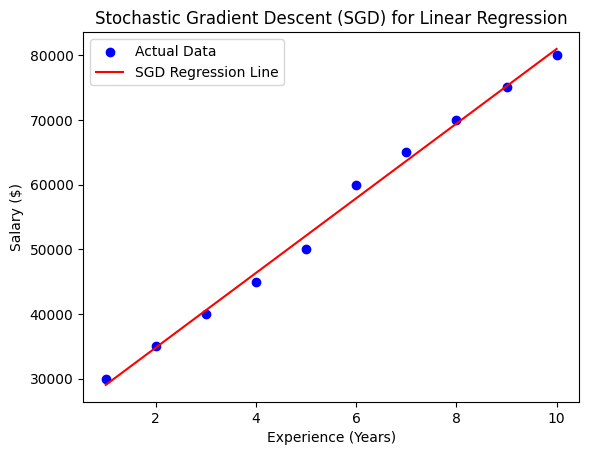

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Sample Data
data = {
    'Experience (Years)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary ($)': [30000, 35000, 40000, 45000, 50000, 60000, 65000, 70000, 75000, 80000]
}
df = pd.DataFrame(data)

# Splitting Features and Target
X = df[['Experience (Years)']]
y = df['Salary ($)']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize Features (SGD requires scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SGD Regressor
sgd = SGDRegressor(learning_rate='constant', eta0=0.01, max_iter=1000, tol=1e-3)
sgd.fit(X_train_scaled, y_train)

# Predictions
y_pred = sgd.predict(X_test_scaled)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
print("SGD Mean Squared Error:", mse)

# Plot Results
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, sgd.predict(scaler.transform(X)), color='red', label="SGD Regression Line")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Stochastic Gradient Descent (SGD) for Linear Regression")
plt.legend()
plt.show()


📊 **Observations:**  
✔ **Red Line** → Best-fitting regression line found by SGD.  
✔ **Blue Points** → Actual data points.  
✔ **Lower MSE** → Indicates good model performance.  

---

## ⚡ **4. Effect of Learning Rate on SGD**  

📌 **The Learning Rate ($ \alpha $) controls step size:**  
- **Too Large** → Overshoots and never converges.  
- **Too Small** → Converges too slowly.  
- **Optimal** → Balances speed and stability.  

### **Visualizing Learning Rate Impact**  

e:\Data Science Materials\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1603: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


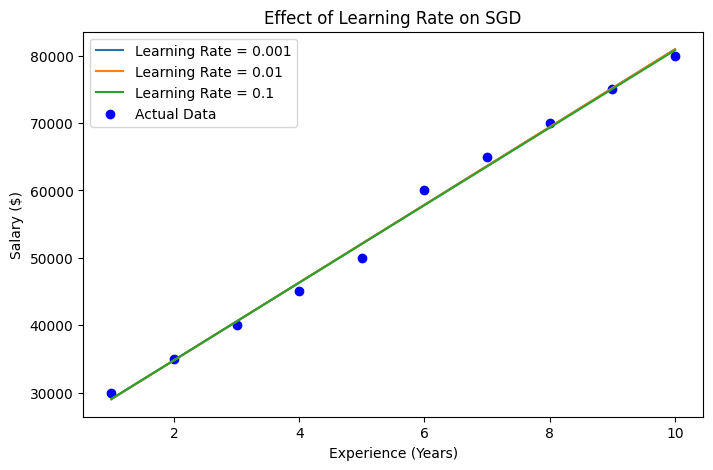

In [2]:
learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    sgd = SGDRegressor(learning_rate='constant', eta0=lr, max_iter=1000, tol=1e-3)
    sgd.fit(X_train_scaled, y_train)
    plt.plot(X, sgd.predict(scaler.transform(X)), label=f"Learning Rate = {lr}")

plt.scatter(X, y, color='blue', label="Actual Data")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Effect of Learning Rate on SGD")
plt.legend()
plt.show()

📌 **Observations:**  
✔ **Small Learning Rate (0.001)** → Converges slowly.  
✔ **Optimal Learning Rate (0.01)** → Smooth convergence.  
✔ **Large Learning Rate (0.1)** → Overshoots and diverges.  

---

## 📉 **5. Effect of Loss Function on SGD**  

📌 **SGD minimizes different loss functions for different ML tasks:**  

| **Loss Function** | **Equation** | **Use Case** |
|------------------|-------------|-------------|
| **Mean Squared Error (MSE)** | $ \frac{1}{n} \sum (Y - \hat{Y})^2 $ | Regression (Linear) |
| **Binary Cross-Entropy** | $ -\sum [Y \log(\hat{Y}) + (1 - Y) \log(1 - \hat{Y})] $ | Logistic Regression |
| **Hinge Loss** | $ \sum \max(0, 1 - Y_i\hat{Y}_i) $ | Support Vector Machines (SVM) |

📌 **Effect:**  
- **For Regression** → Use **MSE Loss**.  
- **For Classification** → Use **Cross-Entropy or Hinge Loss**.  

---

## 📊 **6. Effect of Data on SGD**  

📌 **SGD is sensitive to:**  
✔ **Feature Scaling** → Always standardize input data.  
✔ **Shuffling Data** → Prevents biased updates.  
✔ **Noisy Data** → May cause unstable convergence.  

📌 **Best Practices for Using SGD:**  
1️⃣ **Standardize Data** → Use `StandardScaler()` before applying SGD.  
2️⃣ **Shuffle Training Data** → Helps avoid biased updates.  
3️⃣ **Use Mini-Batch SGD** → Reduces variance in updates.  

---

## 🔄 **7. Universal Use of SGD in Machine Learning**  

📌 **SGD is widely used in ML models:**  

✔ **Linear Regression** → Optimizes **MSE loss**.  
✔ **Logistic Regression** → Uses **Binary Cross-Entropy Loss**.  
✔ **Support Vector Machines (SVMs)** → Optimizes **Hinge Loss**.  
✔ **Deep Learning (Neural Networks)** → Backpropagation uses **SGD variants (Adam, RMSprop, Momentum)**.  

📌 **Variants of SGD Used in Deep Learning:**  
- **Momentum** → Speeds up convergence.  
- **Adam (Adaptive Moment Estimation)** → Combines momentum & adaptive learning rates.  
- **RMSprop** → Scales learning rate based on past gradients.  

---

## 🏆 **8. Key Takeaways**  

✔ **SGD updates parameters after each data point**, making it **faster than batch gradient descent**.  
✔ **Works well for large datasets**, but **introduces noise**.  
✔ **Choosing the right learning rate is critical for convergence.**  
✔ **Feature scaling improves stability** → Always use `StandardScaler()`.  
✔ **SGD is used in Regression, Classification, and Neural Networks.**  

💡 **Pro Tip:** For best results, use **Mini-Batch SGD** (combining benefits of batch & stochastic methods).

---